# Credit Card Fraud Detection

This is my project for detecting fraud in credit card transactions using machine learning.
The dataset is from Kaggle and it has transactions made by European cardholders in September 2013.

I will be using 3 models and comparing them to see which one works best.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

from imblearn.over_sampling import SMOTE

## Loading the Dataset

In [3]:
df = pd.read_csv("../dataset/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Exploratory Data Analysis

In [7]:
# checking for null values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
# checking duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1081


In [9]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [10]:
# how much fraud is there in percentage
fraud_pct = (df["Class"].value_counts()[1] / len(df)) * 100
print(f"Fraud percentage: {fraud_pct:.4f}%")

Fraud percentage: 0.1727%


The dataset is really imbalanced. Only 0.17% transactions are fraud.
This means if the model just predicts everything as genuine it will still get 99.8% accuracy which is wrong.
So I need to handle this imbalance using SMOTE.

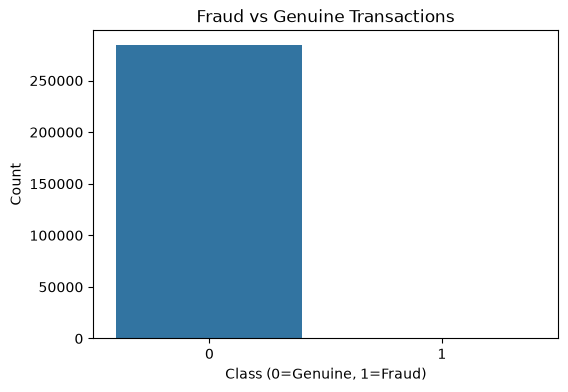

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Class")
plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class (0=Genuine, 1=Fraud)")
plt.ylabel("Count")
plt.savefig("../image/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

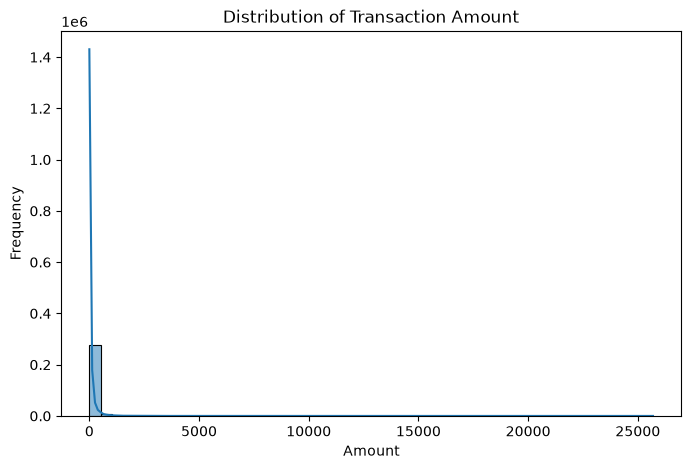

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.savefig("../image/amount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

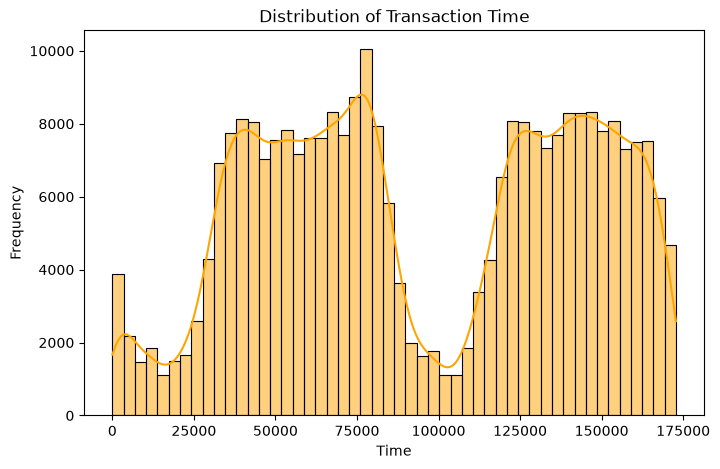

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Time"], bins=50, kde=True, color="orange")
plt.title("Distribution of Transaction Time")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.savefig("../image/time_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Data Preprocessing

### Removing Duplicates

In [14]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (283726, 31)


In [15]:
# just making sure
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### Train Test Split

In [16]:
X = df.drop("Class", axis=1)
y = df["Class"]

print(X.shape)
print(y.shape)

(283726, 30)
(283726,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (226980, 30)
Test size: (56746, 30)


### Scaling

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("done")

done


### Handling Imbalanced Data using SMOTE

In [19]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64


In [20]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


## Model 1 - Logistic Regression

In [21]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_smote, y_train_smote)

print("Training done!")

Training done!


In [22]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [23]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.9736721531033025
Precision: 0.053035143769968054
Recall   : 0.8736842105263158
F1 Score : 0.1


In [24]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



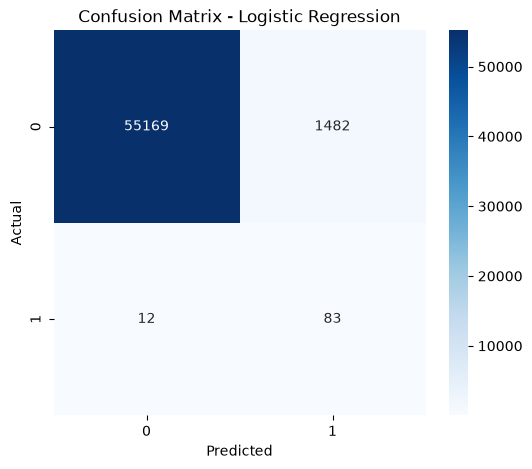

In [25]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../image/confusion_matrix_lr.png", dpi=150, bbox_inches="tight")
plt.show()

## Model 2 - Random Forest

In [26]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

print("Training done!")

Training done!


In [27]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [28]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.9994889507630493
Precision: 0.9125
Recall   : 0.7684210526315789
F1 Score : 0.8342857142857143


In [29]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



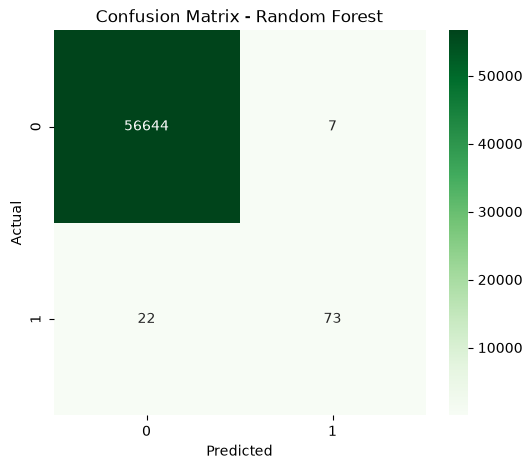

In [30]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../image/confusion_matrix_rf.png", dpi=150, bbox_inches="tight")
plt.show()

## Model 3 - XGBoost

In [31]:
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_model.fit(X_train_smote, y_train_smote)

print("Training done!")

Training done!


In [32]:
y_pred_xgb = xgb_model.predict(X_test_scaled)

In [33]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

Accuracy : 0.9991541254009093
Precision: 0.7281553398058253
Recall   : 0.7894736842105263
F1 Score : 0.7575757575757576


In [34]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.73      0.79      0.76        95

    accuracy                           1.00     56746
   macro avg       0.86      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746



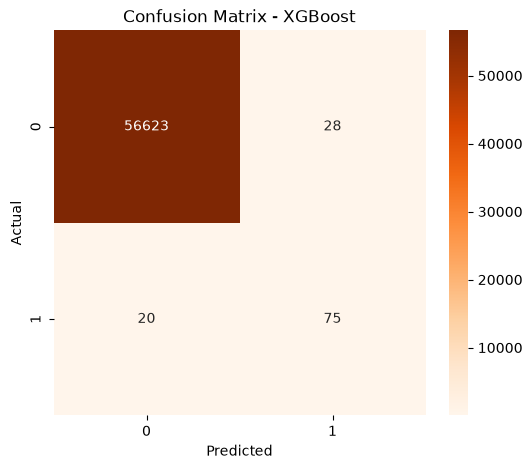

In [35]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../image/confusion_matrix_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

## Comparing All Models

In [36]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.973672,0.053035,0.873684,0.100000
1,Random Forest,0.999489,0.912500,0.768421,0.834286
2,XGBoost,0.999154,0.728155,0.789474,0.757576


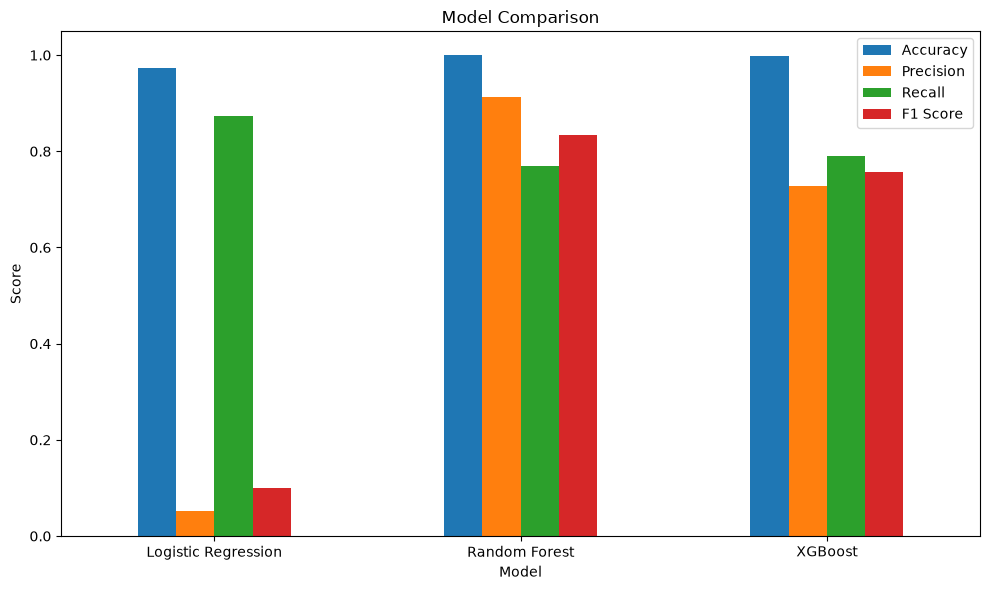

In [37]:
comparison.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../image/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## ROC Curve

In [38]:
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [39]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

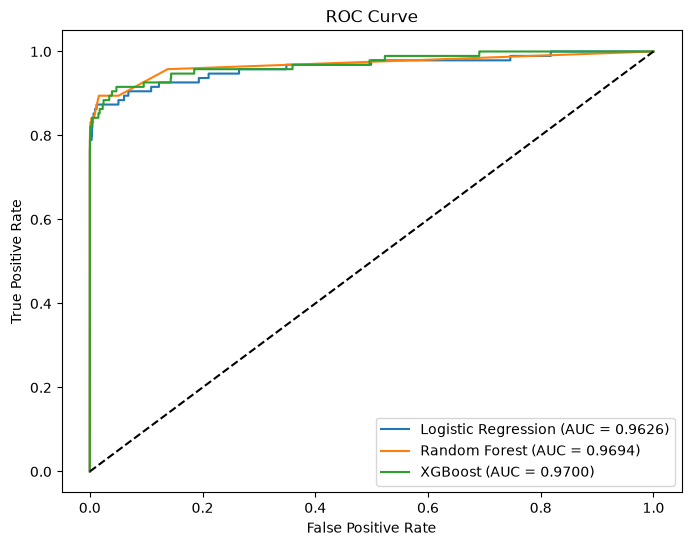

In [40]:
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.4f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.4f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {roc_auc_score(y_test, xgb_probs):.4f})")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("../image/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Feature Importance

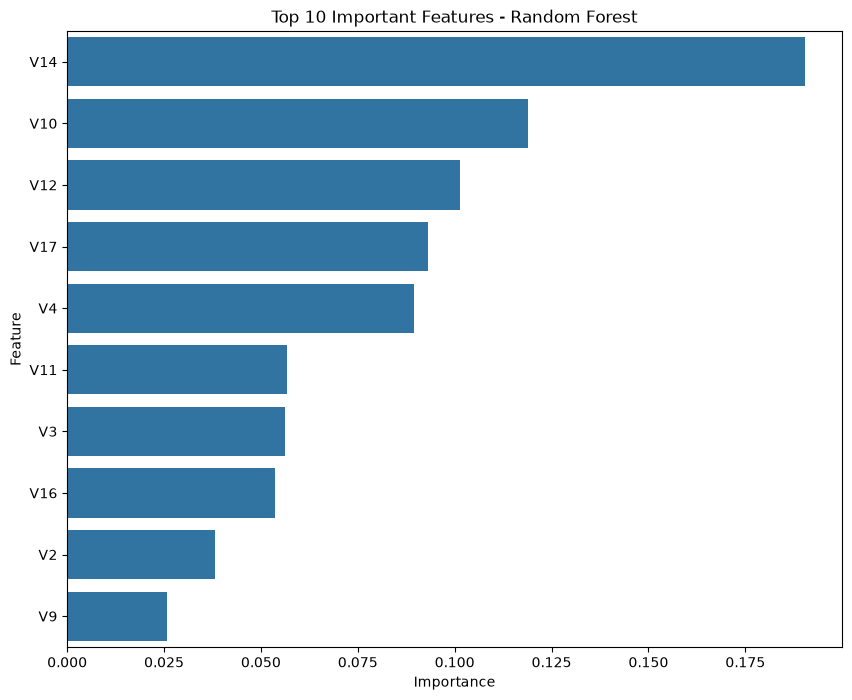

In [41]:
fi = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=fi.head(10), x="Importance", y="Feature")
plt.title("Top 10 Important Features - Random Forest")
plt.savefig("../image/feature_importance_rf.png", dpi=150, bbox_inches="tight")
plt.show()

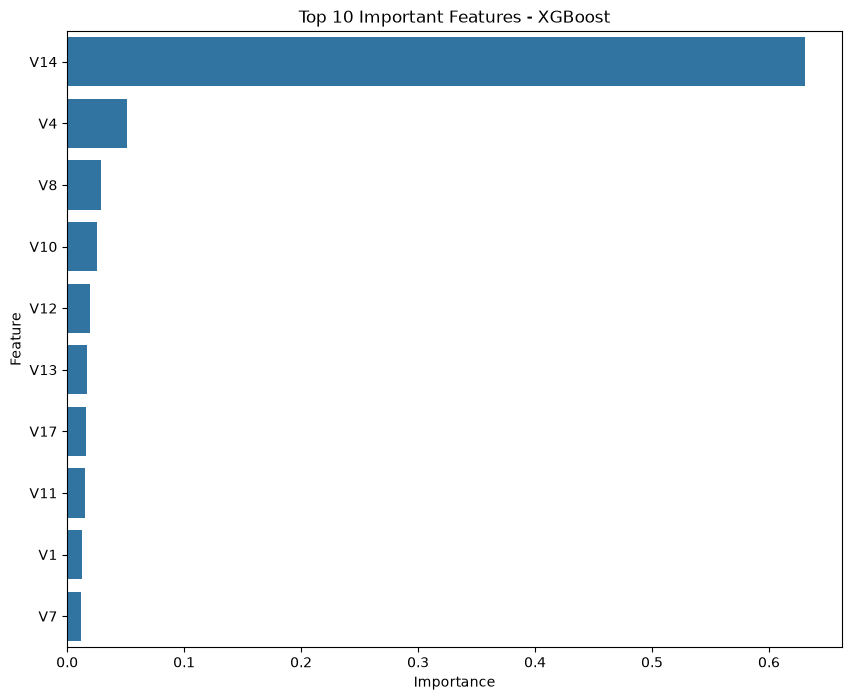

In [42]:
fi_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=fi_xgb.head(10), x="Importance", y="Feature")
plt.title("Top 10 Important Features - XGBoost")
plt.savefig("../image/feature_importance_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

## Saving Models

In [44]:
import joblib

joblib.dump(lr_model, "../model/logistic_regression.pkl")
joblib.dump(rf_model, "../model/random_forest.pkl")
joblib.dump(xgb_model, "../model/xgboost.pkl")
joblib.dump(scaler, "../model/scaler.pkl")

print("All models saved!")

All models saved!


## Conclusion

In this project I built 3 machine learning models to detect credit card fraud.

The dataset was highly imbalanced so I used SMOTE to balance the training data.

After comparing all 3 models using Accuracy, Precision, Recall, F1 Score and ROC-AUC,
XGBoost and Random Forest gave better results compared to Logistic Regression.

For fraud detection, Recall is more important than Accuracy because we dont want to miss any fraud transactions even if it means some false alarms.